<a href="https://colab.research.google.com/github/newtonfalbo/bootcamp-accenture-python-analise-de-dados/blob/main/Bootcamp_Aceenture_Desafio_de_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df ["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


In [3]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount_log"]])

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(["Class"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.70      0.76       148

    accuracy                           1.00     85443
   macro avg       0.92      0.85      0.88     85443
weighted avg       1.00      1.00      1.00     85443



In [10]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [12]:
# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000)) # Increased max_iter to allow convergence
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [24]:
from sklearn.metrics import classification_report

print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.70      0.76       148

    accuracy                           1.00     85443
   macro avg       0.92      0.85      0.88     85443
weighted avg       1.00      1.00      1.00     85443



In [20]:
threshold = 0.3
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.66      0.72       148

    accuracy                           1.00     85443
   macro avg       0.90      0.83      0.86     85443
weighted avg       1.00      1.00      1.00     85443



### Avaliação do Modelo de Regressão Logística com SMOTE Oversampling

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, stratify=y_res, test_size=0.3, random_state=42)


pipeline_smote = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])


pipeline_smote.fit(X_train_res, y_train_res)


y_pred_smote = pipeline_smote.predict(X_test_res)


print("Classification Report for Logistic Regression with SMOTE:")
print(classification_report(y_test_res, y_pred_smote))

Classification Report for Logistic Regression with SMOTE:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     85295
           1       0.99      0.97      0.98     85294

    accuracy                           0.98    170589
   macro avg       0.98      0.98      0.98    170589
weighted avg       0.98      0.98      0.98    170589



### Matriz de Confusão para o Modelo de Regressão Logística com SMOTE

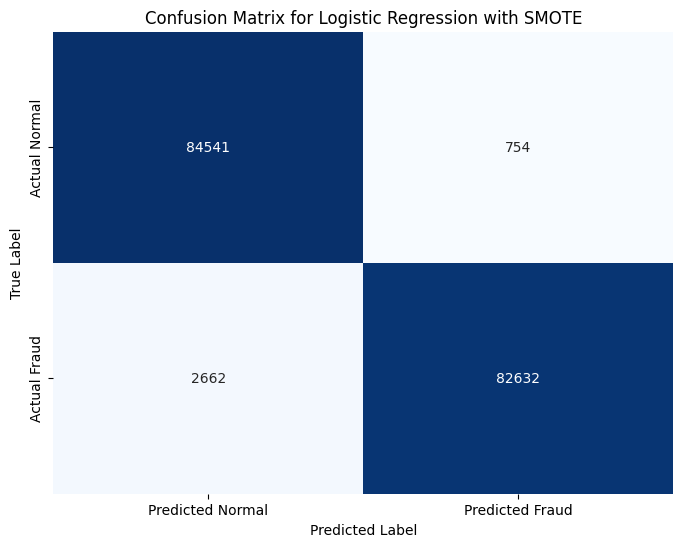

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm_smote = confusion_matrix(y_test_res, y_pred_smote)


plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.title('Confusion Matrix for Logistic Regression with SMOTE')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Otimização de Hiperparâmetros para Regressão Logística com SMOTE usando GridSearchCV

In [29]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2']
}


pipeline_smote_tuned = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, solver='liblinear', random_state=42))
])

# Configura o GridSearchCV
grid_search = GridSearchCV(
    pipeline_smote_tuned,
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1', # Metric to optimize (F1-score is good for imbalanced classes)
    n_jobs=-1 # Use all available cores
)


grid_search.fit(X_train_res, y_train_res)


print("Melhores parâmetros: ", grid_search.best_params_)
print("Melhor pontuação F1: ", grid_search.best_score_)


y_pred_tuned = grid_search.best_estimator_.predict(X_test_res)


print("\nClassification Report for Tuned Logistic Regression with SMOTE:")
print(classification_report(y_test_res, y_pred_tuned))

KeyboardInterrupt: 